# Article 5: Multi-Agent Orchestration Pattern Analysis

This notebook analyses benchmark results from `benchmarks/run_article_05.py`, comparing four LangGraph orchestration patterns (sequential pipeline, critic refinement loop, parallel fan-out, conflict resolution) on a 12-task synthetic workload run 3 times each.

**What the run measures**
- Single framework: LangGraph. CrewAI and AutoGen reference implementations under `examples/article_05_multi_agent/` are architectural references and are not measured here.
- Four patterns from `src/agents/multi_agent.py`: `ResearcherWriterCriticPipeline` (sequential when `max_refinements=0`, critic loop when `max_refinements=2`), `ParallelOrchestrator` with concat aggregation, `VotingResolver` (q006), and `SupervisorResolver` (q011).
- Each pattern runs a different subset of the 12 tasks; aggregates are pattern means, not paired comparisons across the same task set.

**Schema**
- `summaries[]`: per-pattern aggregates (`latency_ms`, `tokens`, `cost_usd`, `llm_calls` with mean/std/min/max). `n_tasks` is the trial count (`runs * unique_task_ids`).
- `tasks[]`: 36 individual trial records (12 tasks * 3 runs), each with `task_id`, `pattern`, `latency_ms`, `total_tokens`, `cost_usd`, `llm_calls`, `output_chars`, optional `critic_score`.

In [1]:
import json
import statistics
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 11

PATTERN_COLORS = {
    "sequential": "#3498db",
    "critic_refinement": "#9b59b6",
    "parallel": "#2ecc71",
    "conflict_resolution": "#e67e22",
}
PATTERN_ORDER = ["sequential", "critic_refinement", "parallel", "conflict_resolution"]

## Load Benchmark Results

In [2]:
PROJECT_ROOT = Path("..").resolve()
RESULTS_DIR = PROJECT_ROOT / "results" / "data"
CHARTS_DIR = PROJECT_ROOT / "results" / "charts" / "article_05"
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

benchmark_file = RESULTS_DIR / "article_05_benchmarks.json"
if not benchmark_file.exists():
    raise FileNotFoundError(
        f"Benchmark file not found: {benchmark_file}\n"
        "Run: uv run python benchmarks/run_article_05.py"
    )

with open(benchmark_file) as f:
    data = json.load(f)

summaries = {s["pattern"]: s for s in data["summaries"]}
tasks = data["tasks"]
tasks_df = pd.DataFrame(tasks)

print(f"Framework:        {data['framework']}")
print(f"Dataset:          {data['dataset']['num_tasks']} tasks, {data['settings']['runs']} runs each")
print(f"Total trials:     {len(tasks_df)}")
print(f"Patterns:         {', '.join(summaries.keys())}")
print()
for p in PATTERN_ORDER:
    s = summaries[p]
    print(f"  {p:22s} trials={s['n_tasks']:2d}  success={s['n_success']:2d}/{s['n_tasks']:2d}  "
          f"latency={s['latency_ms']['mean']:6.0f}ms  tokens={s['tokens']['mean']:5.0f}  "
          f"cost=${s['cost_usd']['mean']:.6f}")

Framework:        langgraph
Dataset:          12 tasks, 3 runs each
Total trials:     36
Patterns:         sequential, parallel, critic_refinement, conflict_resolution

  sequential             trials=12  success=12/12  latency=  3047ms  tokens= 2411  cost=$0.000147
  critic_refinement      trials= 9  success= 9/ 9  latency=  4280ms  tokens= 4164  cost=$0.000253
  parallel               trials= 9  success= 9/ 9  latency=   849ms  tokens= 1685  cost=$0.000111
  conflict_resolution    trials= 6  success= 6/ 6  latency=  1856ms  tokens= 3819  cost=$0.000229


## Chart 1: Latency by Pattern

Mean latency per pattern with std-dev error bars. Bars are pattern means across different task subsets, so the comparison is directional rather than paired. Sequential and critic_refinement share the same pipeline (`ResearcherWriterCriticPipeline`) and only differ in `max_refinements`; the gap between them is the critic loop's overhead. Parallel runs three specialists concurrently with concat aggregation. Conflict resolution combines voting (q006) and supervisor (q011) records.

Saved: /Users/jagdish/work/intellij/py-ws/agentic-ai-stress-suite/results/charts/article_05/01_latency_by_pattern.png


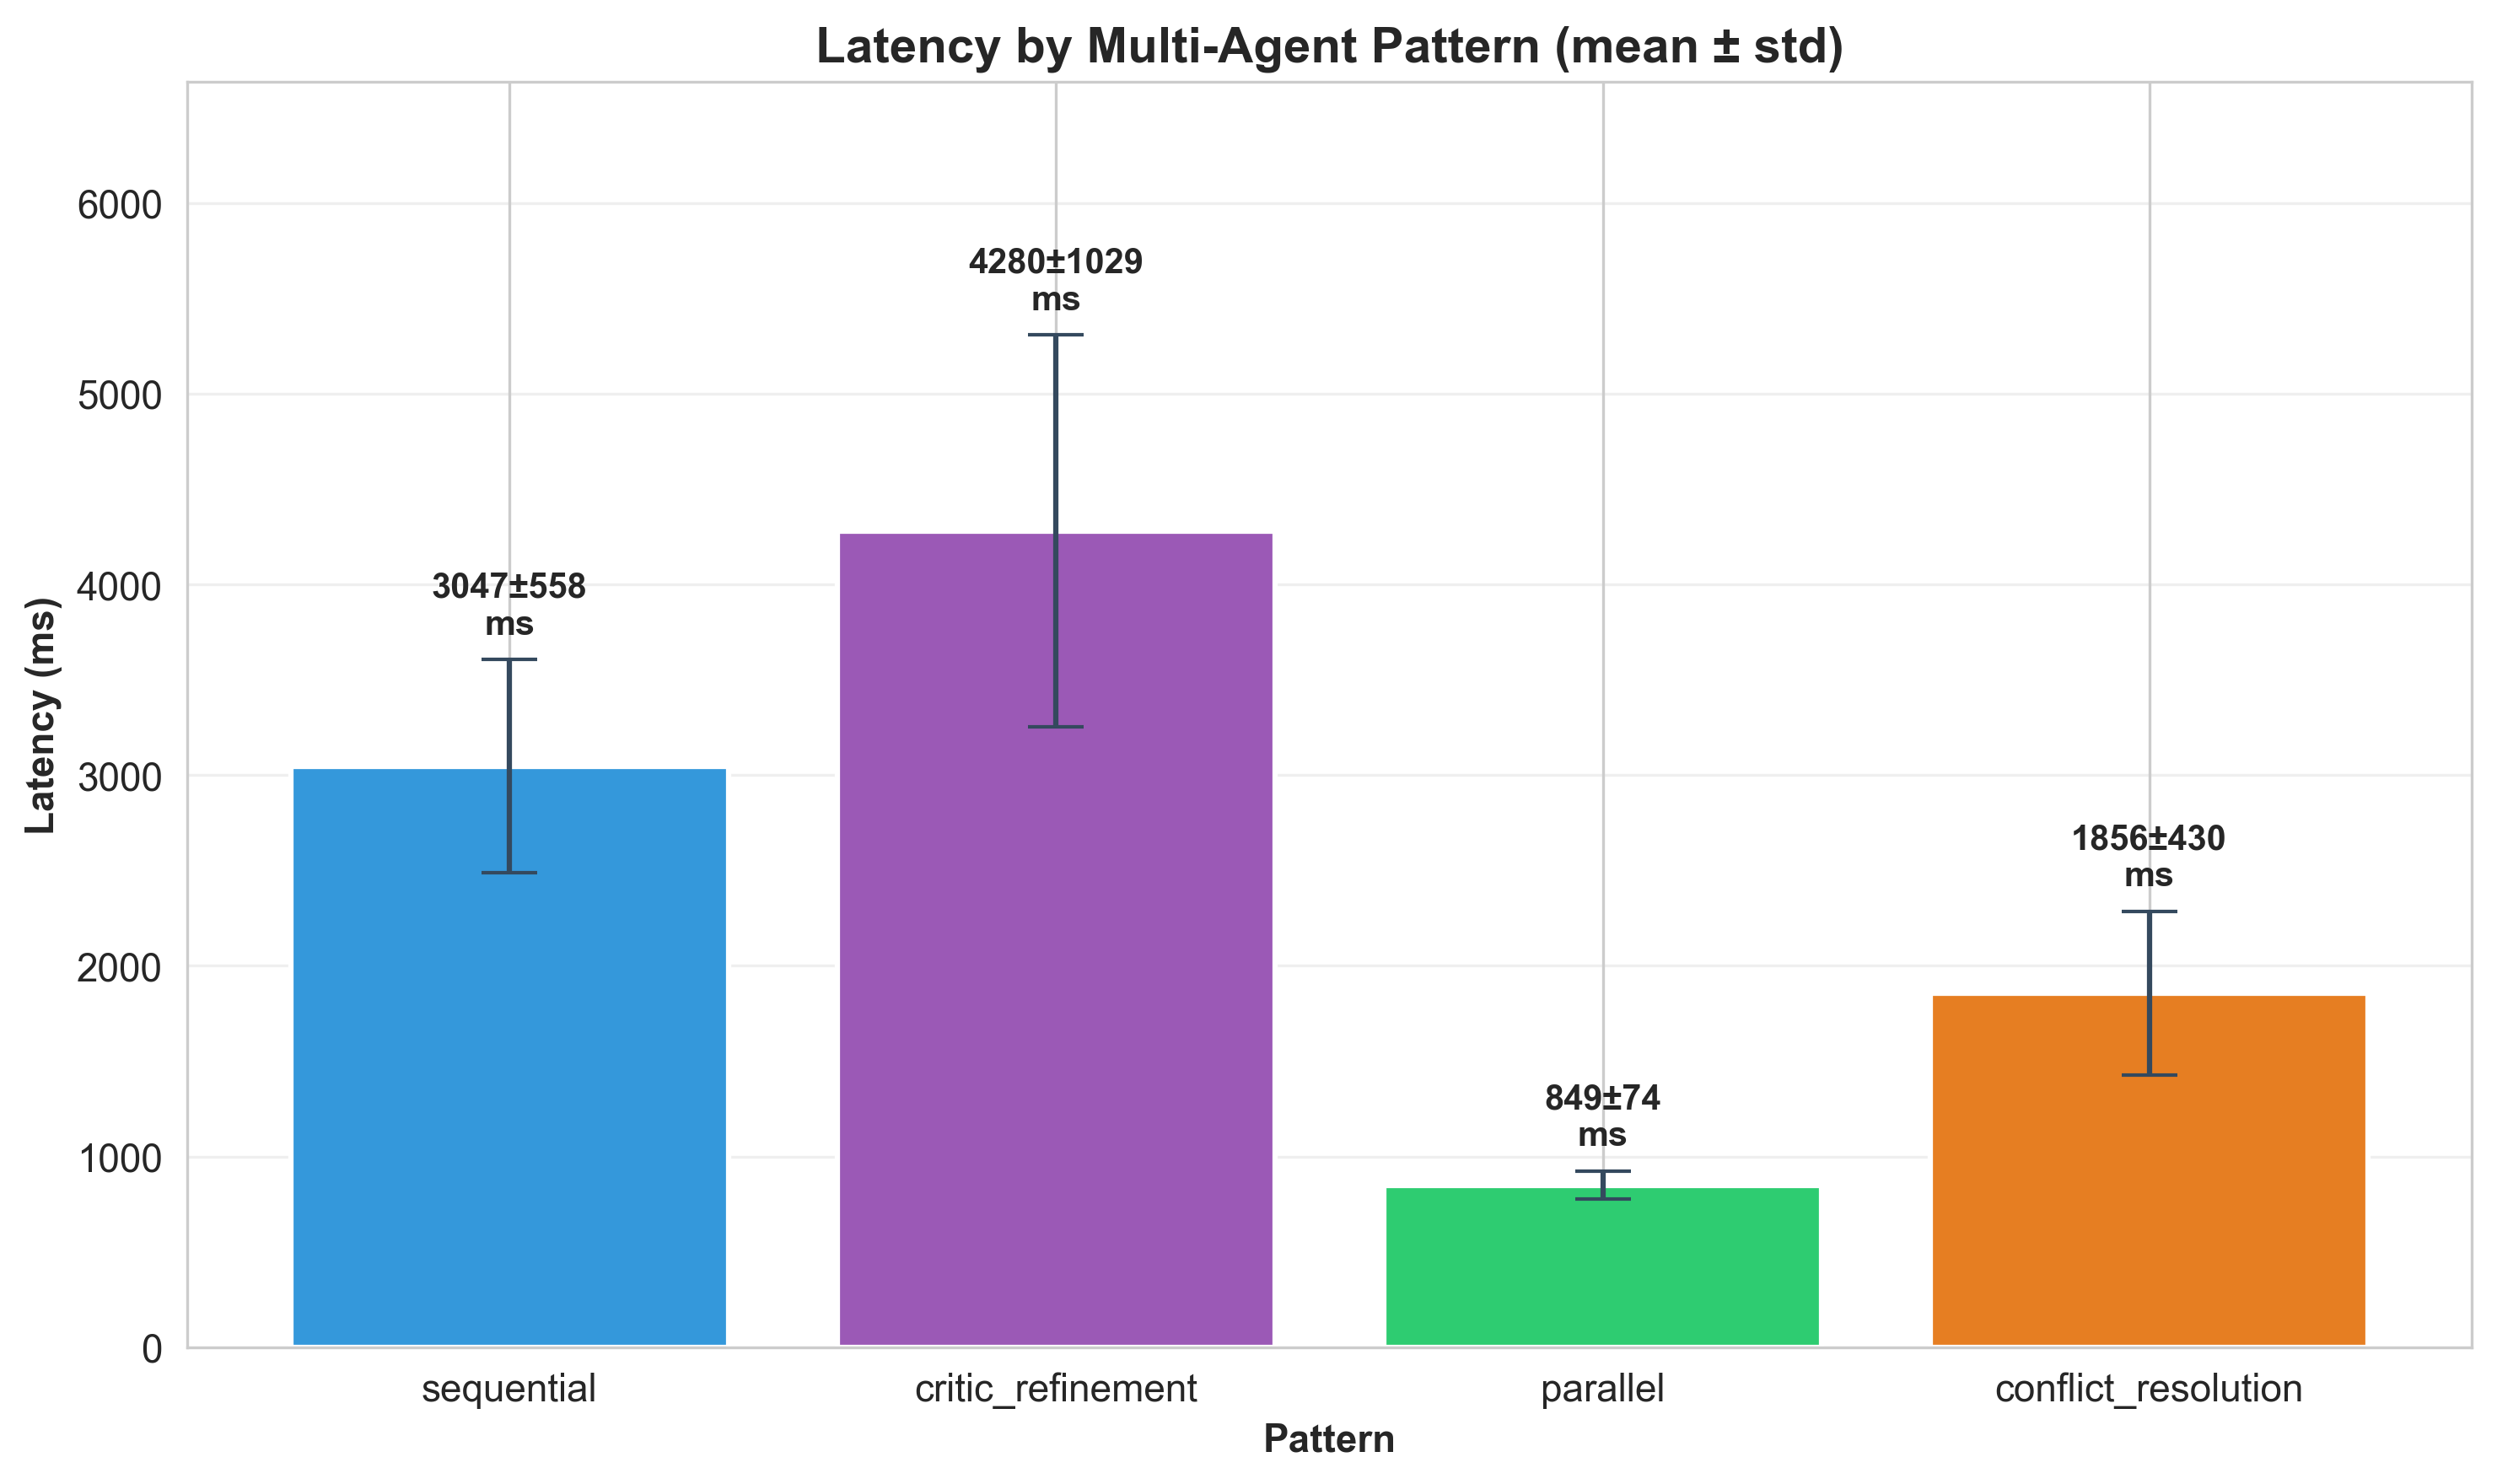

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))

means = [summaries[p]["latency_ms"]["mean"] for p in PATTERN_ORDER]
stds = [summaries[p]["latency_ms"]["std"] for p in PATTERN_ORDER]
colors = [PATTERN_COLORS[p] for p in PATTERN_ORDER]

bars = ax.bar(PATTERN_ORDER, means, yerr=stds, color=colors, capsize=8,
              edgecolor="white", linewidth=1.5, error_kw={"ecolor": "#34495e", "linewidth": 1.5})

for bar, mean, std in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width() / 2, mean + std + 100,
            f"{mean:.0f}\u00b1{std:.0f}\nms",
            ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_xlabel("Pattern", fontweight="bold")
ax.set_ylabel("Latency (ms)", fontweight="bold")
ax.set_title("Latency by Multi-Agent Pattern (mean \u00b1 std)", fontsize=14, fontweight="bold")
ax.set_ylim(0, max(m + s for m, s in zip(means, stds)) * 1.25)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
output_file = CHARTS_DIR / "01_latency_by_pattern.png"
plt.savefig(output_file, dpi=300, bbox_inches="tight")
print(f"Saved: {output_file}")
plt.show()

## Chart 2: Token and Cost by Pattern

Two-panel comparison of mean tokens and mean cost per task. Critic refinement is the most expensive pattern in absolute terms because the loop fires on roughly half the trials and each iteration adds a writer + critic round. Parallel is the cheapest because the three specialists each emit a single LLM call without re-reading each other's output. Conflict resolution sits in the middle and is dominated by the voting branch (q006), which produces full-text candidates.

Saved: /Users/jagdish/work/intellij/py-ws/agentic-ai-stress-suite/results/charts/article_05/02_tokens_and_cost_by_pattern.png


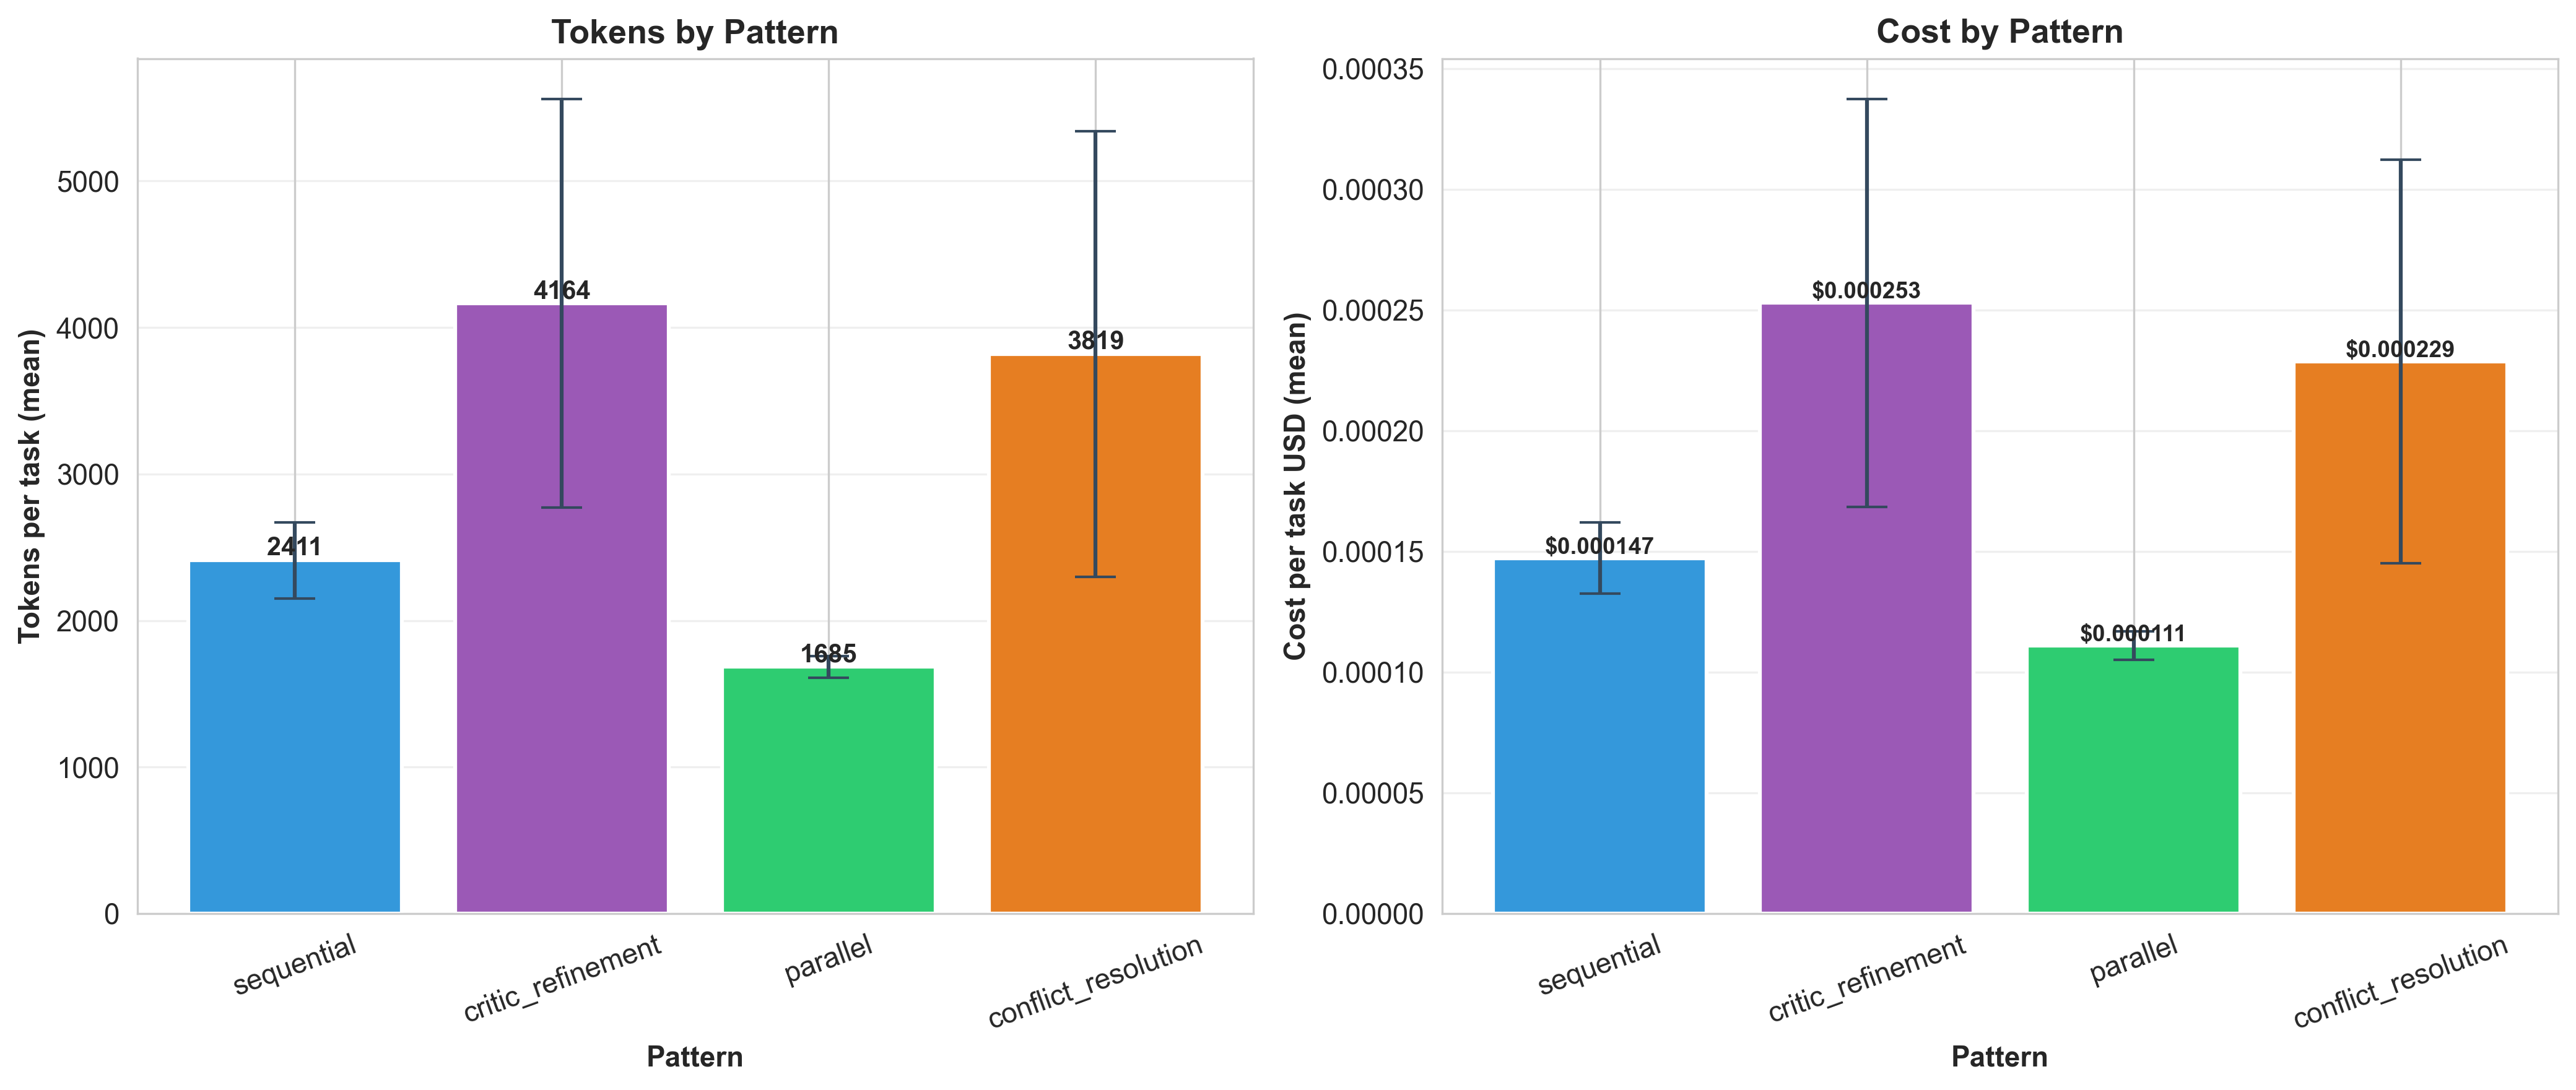

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

token_means = [summaries[p]["tokens"]["mean"] for p in PATTERN_ORDER]
token_stds = [summaries[p]["tokens"]["std"] for p in PATTERN_ORDER]
cost_means = [summaries[p]["cost_usd"]["mean"] for p in PATTERN_ORDER]
cost_stds = [summaries[p]["cost_usd"]["std"] for p in PATTERN_ORDER]
colors = [PATTERN_COLORS[p] for p in PATTERN_ORDER]

bars1 = ax1.bar(PATTERN_ORDER, token_means, yerr=token_stds, color=colors,
                capsize=8, edgecolor="white", linewidth=1.5,
                error_kw={"ecolor": "#34495e", "linewidth": 1.5})
for bar, mean in zip(bars1, token_means):
    ax1.text(bar.get_x() + bar.get_width() / 2, mean,
             f"{mean:.0f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax1.set_xlabel("Pattern", fontweight="bold")
ax1.set_ylabel("Tokens per task (mean)", fontweight="bold")
ax1.set_title("Tokens by Pattern", fontsize=13, fontweight="bold")
ax1.tick_params(axis="x", rotation=20)
ax1.grid(axis="y", alpha=0.3)

bars2 = ax2.bar(PATTERN_ORDER, cost_means, yerr=cost_stds, color=colors,
                capsize=8, edgecolor="white", linewidth=1.5,
                error_kw={"ecolor": "#34495e", "linewidth": 1.5})
for bar, mean in zip(bars2, cost_means):
    ax2.text(bar.get_x() + bar.get_width() / 2, mean,
             f"${mean:.6f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax2.set_xlabel("Pattern", fontweight="bold")
ax2.set_ylabel("Cost per task USD (mean)", fontweight="bold")
ax2.set_title("Cost by Pattern", fontsize=13, fontweight="bold")
ax2.tick_params(axis="x", rotation=20)
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
output_file = CHARTS_DIR / "02_tokens_and_cost_by_pattern.png"
plt.savefig(output_file, dpi=300, bbox_inches="tight")
print(f"Saved: {output_file}")
plt.show()

## Chart 3: Per-Trial Latency Distribution

Box plot of all 36 individual trial latencies grouped by pattern. This exposes within-pattern variance that the bar chart hides. Critic refinement has the widest spread because some trials run the loop and others don't (`refinement_count` is 0 for ~half the records). Conflict resolution shows two clusters: the voting branch (q006, ~2-2.5s) and the supervisor branch (q011, ~1.4s).

Saved: /Users/jagdish/work/intellij/py-ws/agentic-ai-stress-suite/results/charts/article_05/03_latency_distribution.png


/var/folders/zm/vdkmvw8j2qx3097ct01h3sbh0000gn/T/ipykernel_3931/4135007997.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_pattern, labels=PATTERN_ORDER, patch_artist=True,


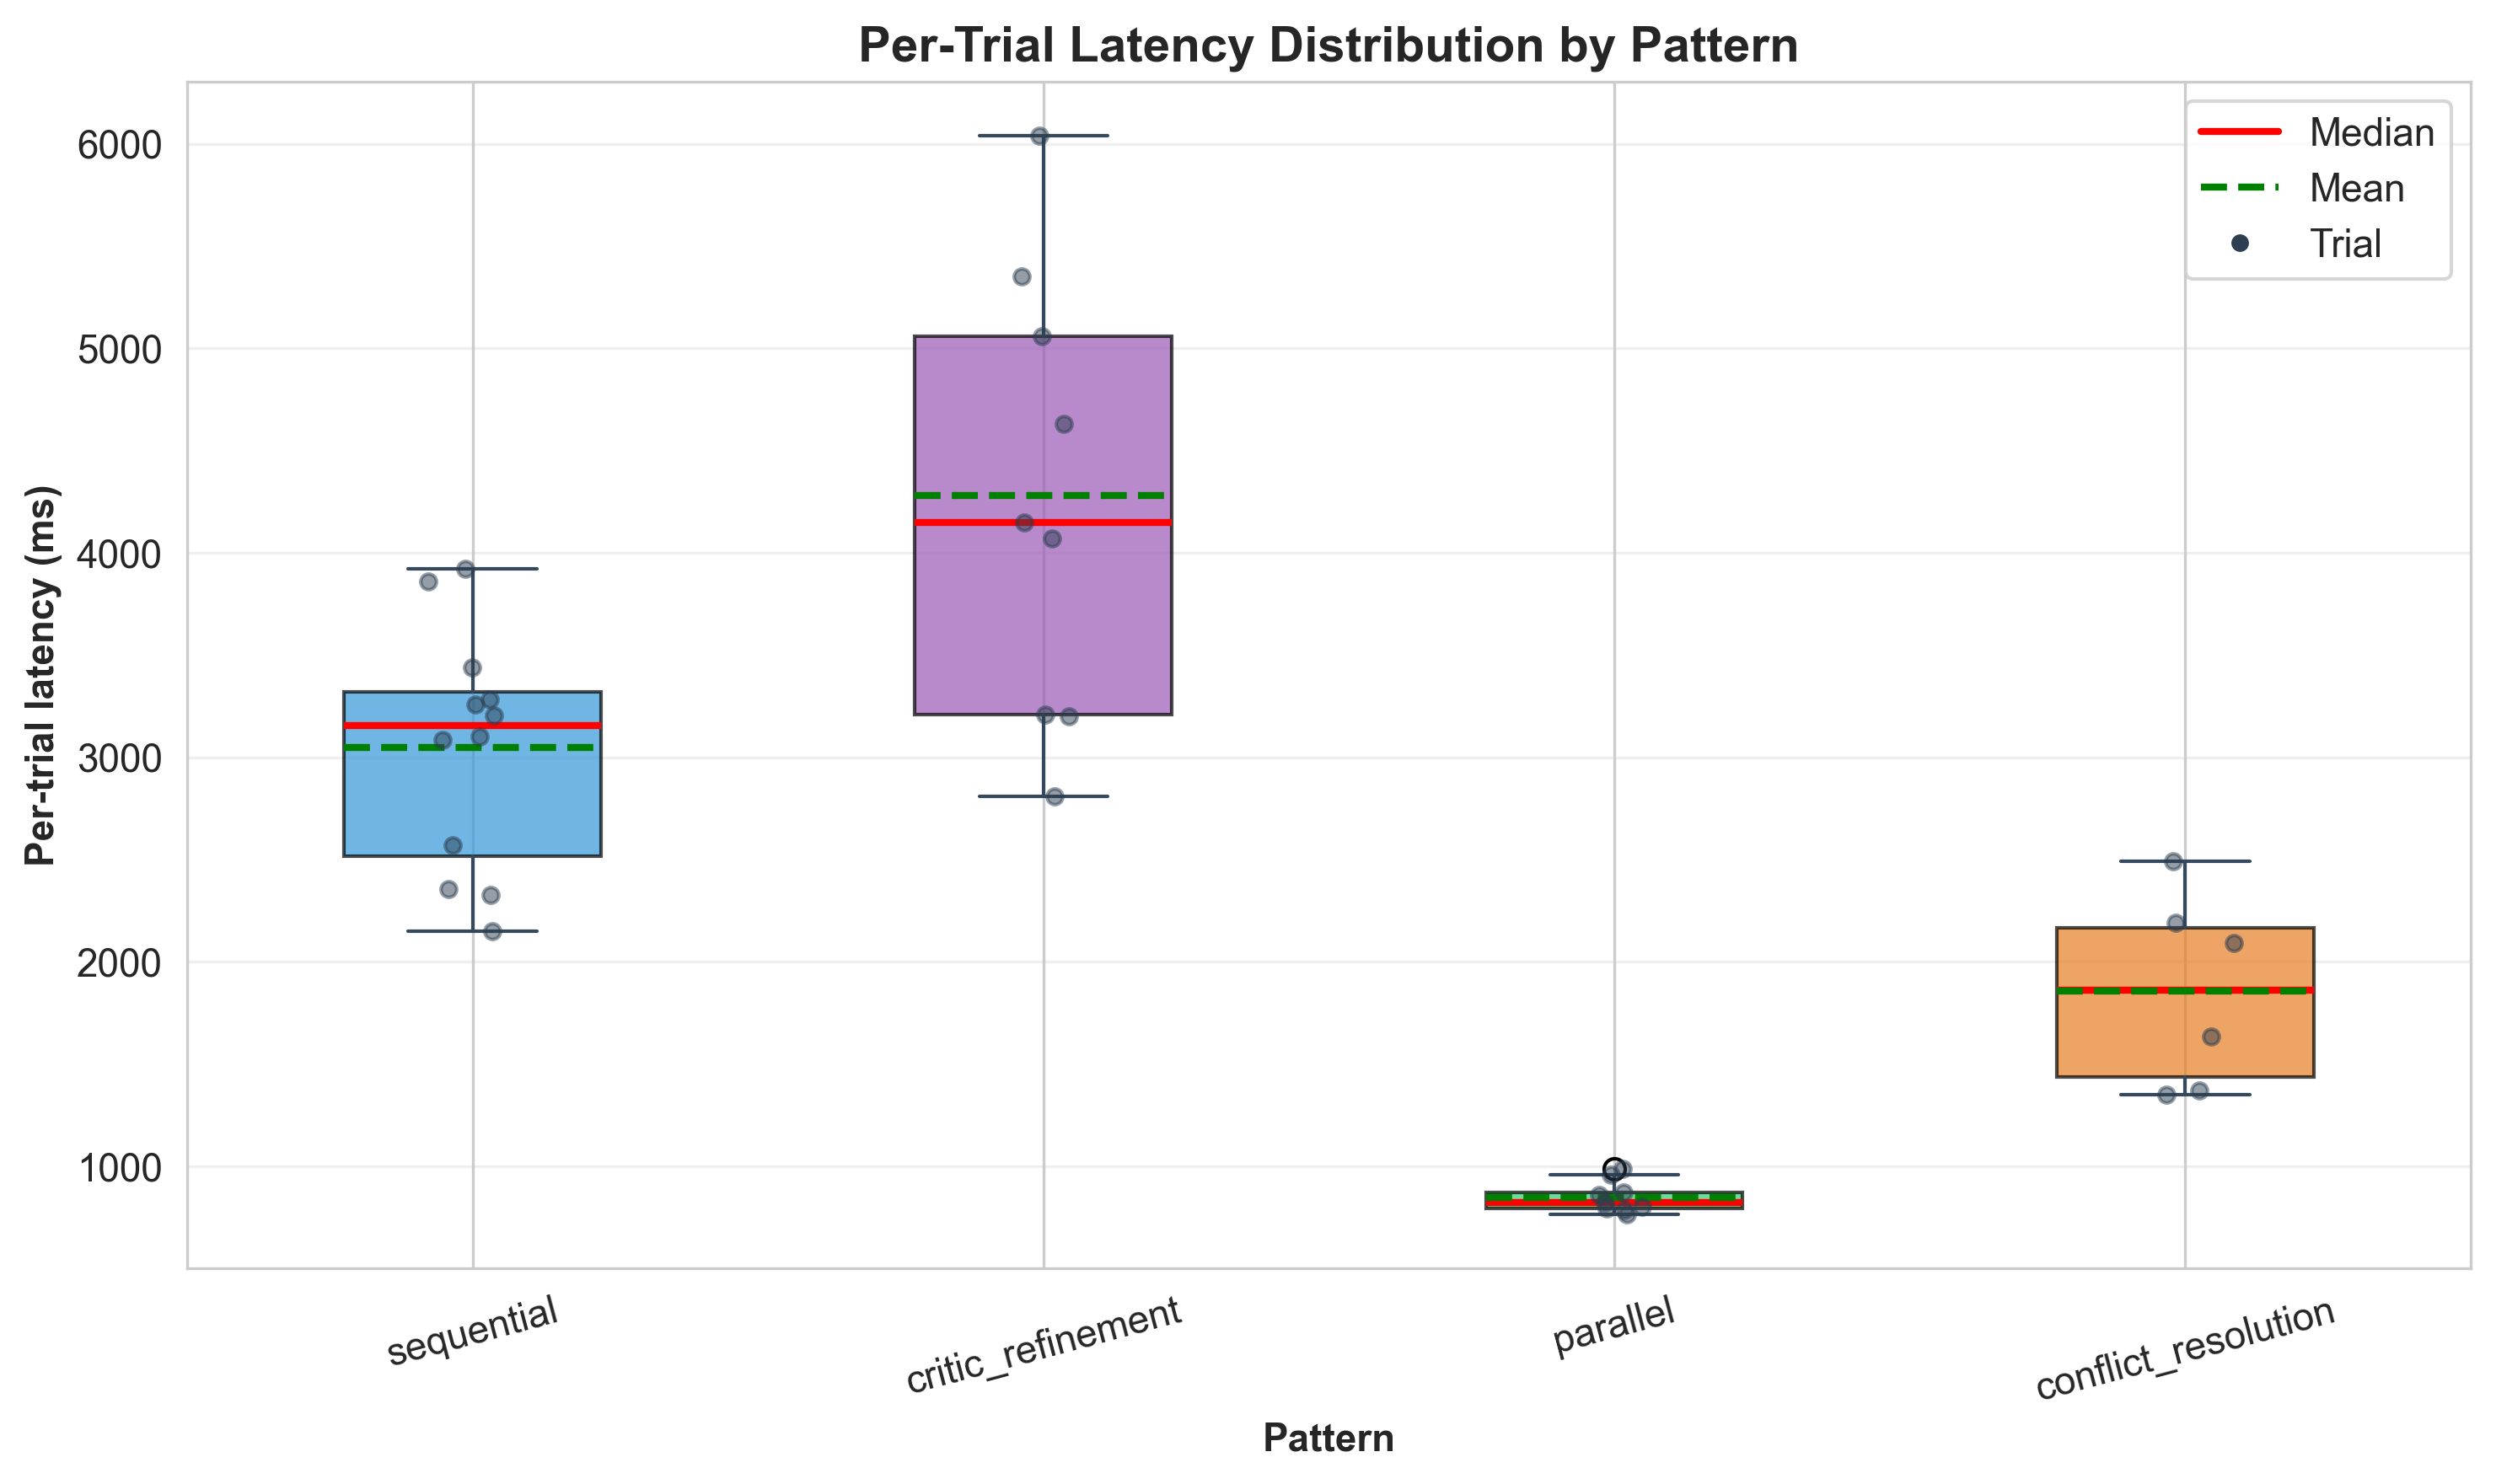

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

data_by_pattern = [tasks_df[tasks_df["pattern"] == p]["latency_ms"].tolist() for p in PATTERN_ORDER]

bp = ax.boxplot(data_by_pattern, labels=PATTERN_ORDER, patch_artist=True,
                showmeans=True, meanline=True,
                boxprops=dict(alpha=0.7),
                medianprops=dict(color="red", linewidth=2),
                meanprops=dict(color="green", linewidth=2, linestyle="--"),
                whiskerprops=dict(color="#34495e"),
                capprops=dict(color="#34495e"))

for patch, p in zip(bp["boxes"], PATTERN_ORDER):
    patch.set_facecolor(PATTERN_COLORS[p])

rng = np.random.default_rng(seed=42)
for i, lats in enumerate(data_by_pattern, start=1):
    x_jitter = rng.normal(i, 0.04, size=len(lats))
    ax.scatter(x_jitter, lats, alpha=0.5, color="#2c3e50", s=20, zorder=3)

ax.set_xlabel("Pattern", fontweight="bold")
ax.set_ylabel("Per-trial latency (ms)", fontweight="bold")
ax.set_title("Per-Trial Latency Distribution by Pattern", fontsize=14, fontweight="bold")
ax.tick_params(axis="x", rotation=15)
ax.grid(axis="y", alpha=0.3)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color="red", linewidth=2, label="Median"),
    Line2D([0], [0], color="green", linewidth=2, linestyle="--", label="Mean"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#2c3e50", markersize=6, label="Trial"),
]
ax.legend(handles=legend_elements, loc="upper right")

plt.tight_layout()
output_file = CHARTS_DIR / "03_latency_distribution.png"
plt.savefig(output_file, dpi=300, bbox_inches="tight")
print(f"Saved: {output_file}")
plt.show()

## Chart 4: Conflict Resolution Split (Voting vs Supervisor)

The conflict resolution pattern routes q006 to `VotingResolver` (3 candidates, returns the candidate with the most votes including its full text) and q011 to `SupervisorResolver` (2 candidates plus an arbitrator LLM that returns a `DECISION:` substring). Comparing them on a single chart hides two real differences: the supervisor variant runs fewer LLM calls per trial and the runner persists less of its output to the JSON (only the substring after `DECISION:`, not the `REASONING:` block).

This chart isolates the two variants on latency, tokens, and `output_chars` so the asymmetry is visible.

Saved: /Users/jagdish/work/intellij/py-ws/agentic-ai-stress-suite/results/charts/article_05/04_conflict_resolution_split.png


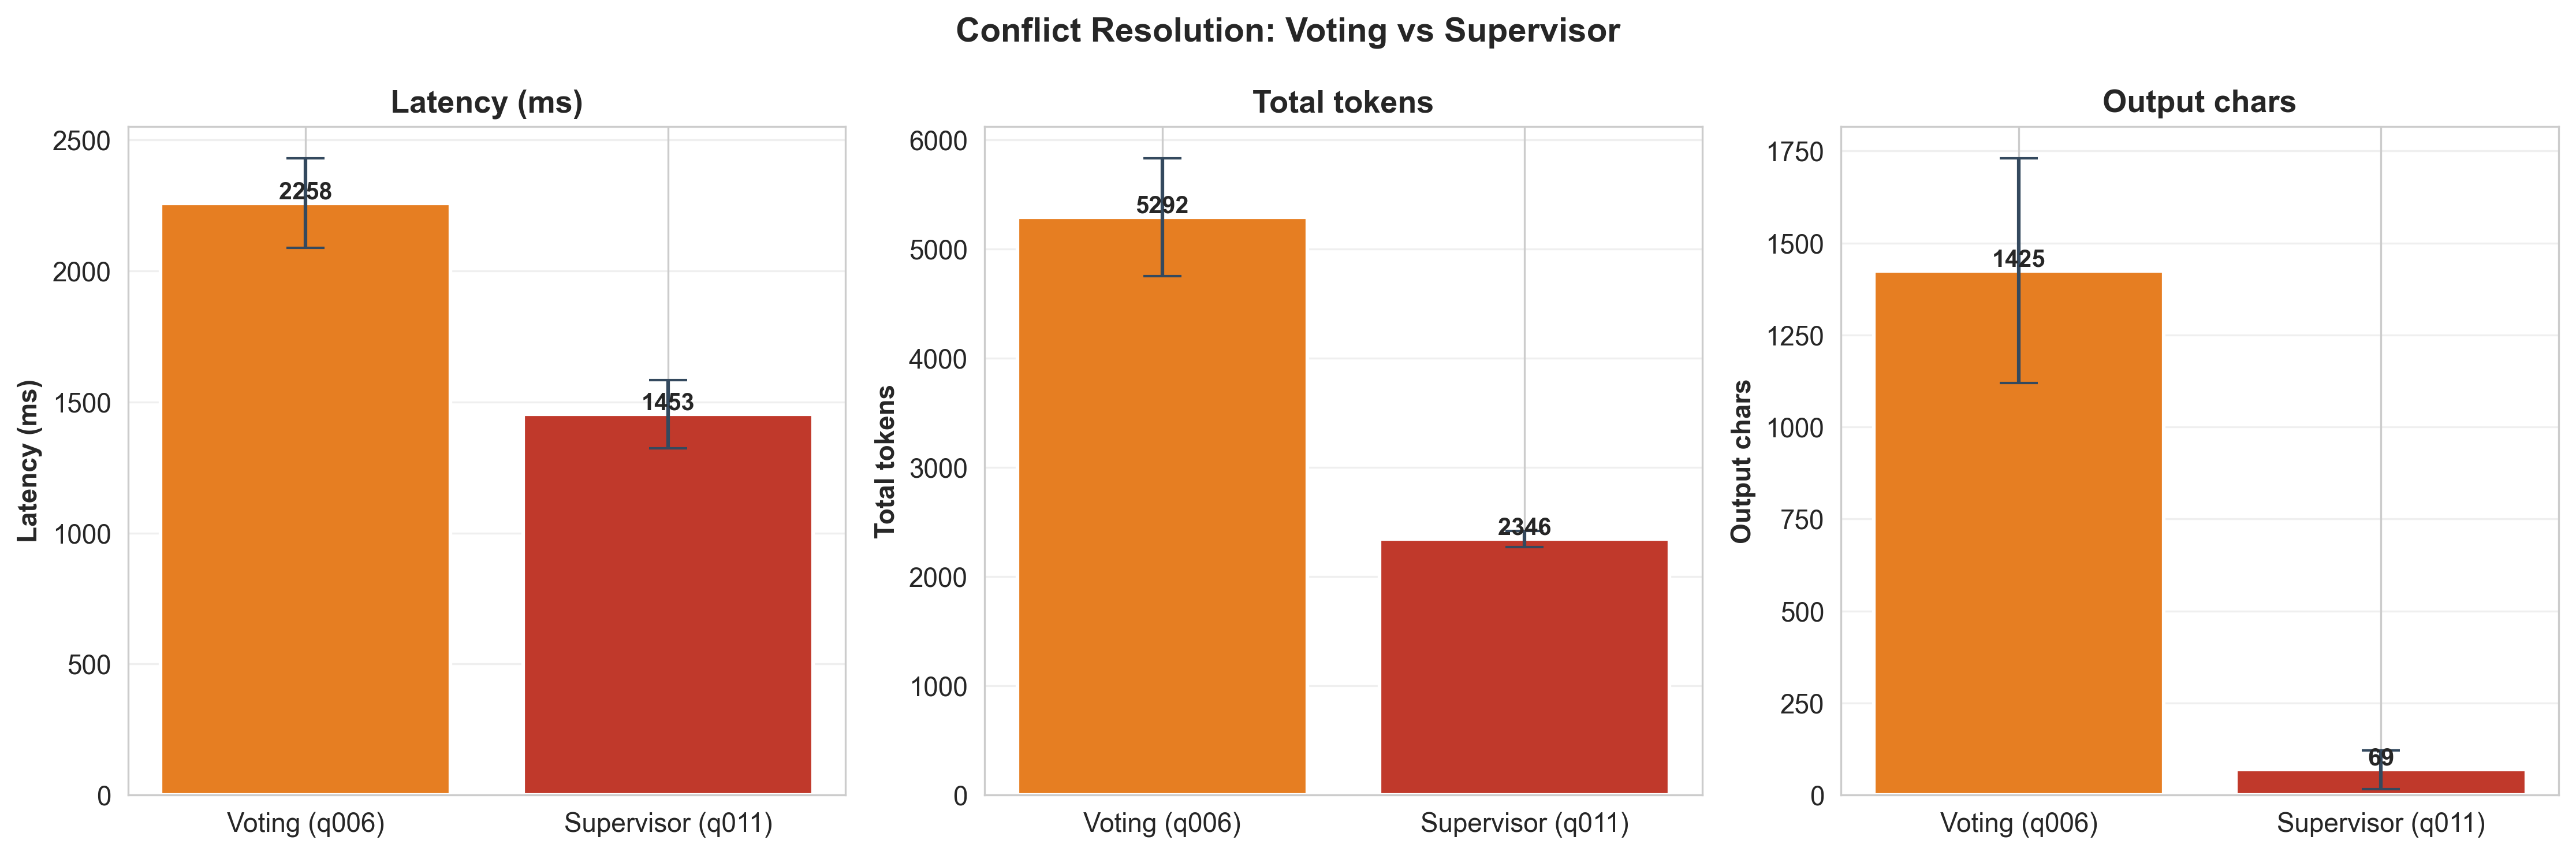

In [6]:
voting_df = tasks_df[tasks_df["task_id"] == "q006"]
supervisor_df = tasks_df[tasks_df["task_id"] == "q011"]

metrics = {
    "Latency (ms)": ("latency_ms", "{:.0f}"),
    "Total tokens": ("total_tokens", "{:.0f}"),
    "Output chars": ("output_chars", "{:.0f}"),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (label, (col, fmt)) in zip(axes, metrics.items()):
    voting_vals = voting_df[col].tolist()
    supervisor_vals = supervisor_df[col].tolist()
    means = [statistics.mean(voting_vals), statistics.mean(supervisor_vals)]
    stds = [statistics.pstdev(voting_vals), statistics.pstdev(supervisor_vals)]
    bars = ax.bar(
        ["Voting (q006)", "Supervisor (q011)"], means, yerr=stds,
        color=["#e67e22", "#c0392b"], capsize=8, edgecolor="white", linewidth=1.5,
        error_kw={"ecolor": "#34495e", "linewidth": 1.5},
    )
    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2, mean,
                fmt.format(mean), ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.set_title(label, fontsize=13, fontweight="bold")
    ax.set_ylabel(label, fontweight="bold")
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Conflict Resolution: Voting vs Supervisor", fontsize=14, fontweight="bold")
plt.tight_layout()
output_file = CHARTS_DIR / "04_conflict_resolution_split.png"
plt.savefig(output_file, dpi=300, bbox_inches="tight")
print(f"Saved: {output_file}")
plt.show()

## Summary Table

In [7]:
rows = []
for p in PATTERN_ORDER:
    s = summaries[p]
    rows.append({
        "Pattern": p,
        "Trials": s["n_tasks"],
        "Success": f"{s['n_success']}/{s['n_tasks']}",
        "Latency mean\u00b1std (ms)": f"{s['latency_ms']['mean']:.0f} \u00b1 {s['latency_ms']['std']:.0f}",
        "Latency min/max (ms)": f"{s['latency_ms']['min']:.0f} / {s['latency_ms']['max']:.0f}",
        "LLM calls mean/min/max": f"{s['llm_calls']['mean']:.1f} / {s['llm_calls']['min']:.0f}-{s['llm_calls']['max']:.0f}",
        "Tokens mean\u00b1std": f"{s['tokens']['mean']:.0f} \u00b1 {s['tokens']['std']:.0f}",
        "Cost mean ($)": f"{s['cost_usd']['mean']:.6f}",
    })
summary_table = pd.DataFrame(rows)
print("Pattern Summary")
print("=" * 130)
print(summary_table.to_string(index=False))
print("=" * 130)

voting = tasks_df[tasks_df["task_id"] == "q006"]
supervisor = tasks_df[tasks_df["task_id"] == "q011"]
print("\nConflict Resolution Split")
print("=" * 130)
for label, df in [("Voting (q006)", voting), ("Supervisor (q011)", supervisor)]:
    print(f"  {label:22s} trials={len(df):2d}  "
          f"latency={df['latency_ms'].mean():.0f}\u00b1{statistics.pstdev(df['latency_ms']):.0f}ms  "
          f"tokens={df['total_tokens'].mean():.0f}\u00b1{statistics.pstdev(df['total_tokens']):.0f}  "
          f"output_chars={df['output_chars'].mean():.0f}  "
          f"llm_calls={df['llm_calls'].mean():.1f}  "
          f"cost=${df['cost_usd'].mean():.6f}")
print("=" * 130)

Pattern Summary
            Pattern  Trials Success Latency mean±std (ms) Latency min/max (ms) LLM calls mean/min/max Tokens mean±std Cost mean ($)
         sequential      12   12/12            3047 ± 558          2151 / 3921              3.0 / 3-3      2411 ± 261      0.000147
  critic_refinement       9     9/9           4280 ± 1029          2810 / 6040              4.3 / 3-7     4164 ± 1395      0.000253
           parallel       9     9/9              849 ± 74            764 / 988              3.0 / 3-3       1685 ± 73      0.000111
conflict_resolution       6     6/6            1856 ± 430          1351 / 2494              4.5 / 3-6     3819 ± 1522      0.000229

Conflict Resolution Split
  Voting (q006)          trials= 3  latency=2258±172ms  tokens=5292±540  output_chars=1425  llm_calls=6.0  cost=$0.000309
  Supervisor (q011)      trials= 3  latency=1453±130ms  tokens=2346±73  output_chars=69  llm_calls=3.0  cost=$0.000148


## Results Interpretation

### What this run measures

Single-framework (LangGraph) benchmark of four orchestration patterns from `src/agents/multi_agent.py`:
- **sequential** (4 tasks * 3 runs = 12 trials): `ResearcherWriterCriticPipeline` with `max_refinements=0`. Researcher then Writer then Critic, no loop.
- **critic_refinement** (3 tasks * 3 runs = 9 trials): the same pipeline with `max_refinements=2`. Loop fires when the critic returns a score below threshold.
- **parallel** (3 tasks * 3 runs = 9 trials): `ParallelOrchestrator` with three specialists running concurrently and concat aggregation.
- **conflict_resolution** (2 tasks * 3 runs = 6 trials): specialists fan out and a resolver picks the winner. q006 routes to `VotingResolver`, q011 to `SupervisorResolver`.

Each pattern runs a different subset of the 12 tasks. Pattern means are not paired comparisons.

### Headline findings

1. **Parallel is the cheapest pattern by every metric.** ~849ms latency, ~1685 tokens, ~$0.000111 per trial. Three specialists fire concurrently and each emits a single LLM call.
2. **Critic refinement is roughly 1.7x the sequential baseline in tokens and dollars** (4164 vs 2411 tokens; $0.000253 vs $0.000147). This is a pattern-mean comparison across different task subsets, not a per-refinement cost slope.
3. **Voting resolves conflicts at higher cost than supervisor** ($0.000309 vs $0.000148, 6 LLM calls vs 3). The 2x token gap is partly because voting persists full candidate text while the runner only persists the supervisor's `DECISION:` substring.
4. **Success rate is 100% across all 36 trials.** This benchmark does not measure output quality; the success flag only checks that the pipeline ran to completion. Critic-loop trials report `critic_score=4` (out of 5) on every observed record because the parser defaults to 3 on failure and clamps to 1-5 - the constant value is the critic genuinely returning 4, not a parser artefact.

### Limitations

- **No quality scores.** The benchmark measures latency, tokens, cost, and call counts. It does not measure whether the answer is correct, complete, or grounded. LLM-as-judge or human evaluation is the right tool for that.
- **Sequential and critic_refinement are not the same workflow with one knob flipped.** They run different task subsets. The 1.7x cost gap is directional, not a within-task slope.
- **No framework comparison numbers.** CrewAI and AutoGen implementations under `examples/article_05_multi_agent/` are reference architectures. Only LangGraph is measured.
- **Conflict resolution mixes two different resolvers.** q006 (voting) and q011 (supervisor) are aggregated under one pattern label. Chart 4 isolates them.
- **Round-Robin debate (`RoundRobinResolver`) is not measured.** Implementation lives in `src/agents/multi_agent.py` but is not exercised by the runner.
- **Supervisor `output_chars` is asymmetric.** The runner persists only the `DECISION:` substring (line 318 of `benchmarks/run_article_05.py`); voting persists the full winner text. Don't compare `output_chars` across the two variants without that caveat in mind.

## Export Complete

Charts written to `results/charts/article_05/`:
- `01_latency_by_pattern.png`
- `02_tokens_and_cost_by_pattern.png`
- `03_latency_distribution.png`
- `04_conflict_resolution_split.png`